## Roadpoles_v1

In [1]:
import os
import supervision as sv
import cv2
import numpy as np

train 322
valid 92
test 46

tandv=414


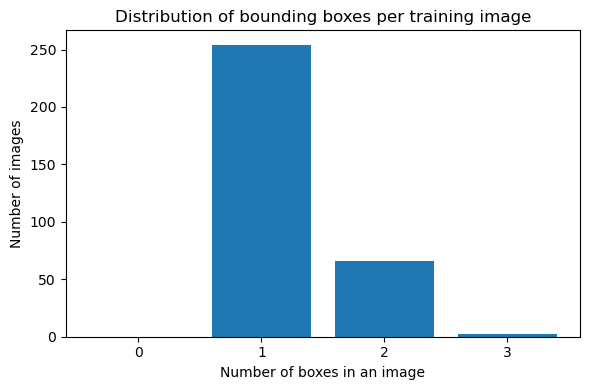

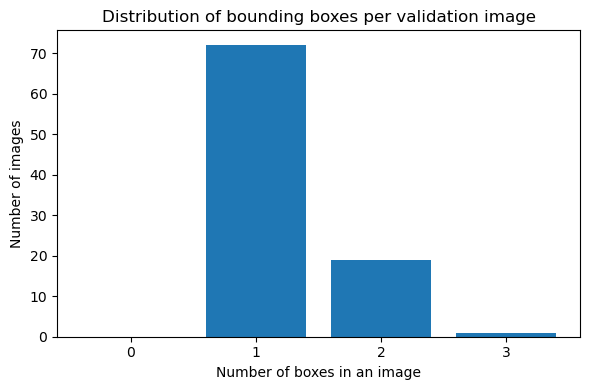

In [2]:
paths = ['/cluster/projects/vc/courses/TDT17/ad/Poles2025/roadpoles_v1/train/images/',
         '/cluster/projects/vc/courses/TDT17/ad/Poles2025/roadpoles_v1/valid/images/',
         '/cluster/projects/vc/courses/TDT17/ad/Poles2025/roadpoles_v1/test/images/']
namepath = ['train', 'valid', 'test']
total = 0
tandv = 0
for name, path in zip(namepath, paths):
    print(name, len(os.listdir(path)))
    if name != 'test':
        tandv +=len(os.listdir(path))
print()
print(f'{tandv=}')


train_label_folder_path = '/cluster/projects/vc/courses/TDT17/ad/Poles2025/roadpoles_v1/train/labels/' # .txt
train_frames = []
for fname in os.listdir(train_label_folder_path):
    train_frames.append(fname[:-4])

train_boxes = []
for i in range(0, len(train_frames)):
    frame = train_frames[i]
    label_path = os.path.join(train_label_folder_path, frame + '.txt')
    line_counter = 0
    for line in open(label_path):
        line_counter += 1
    train_boxes.append(line_counter)
len(train_boxes)

import matplotlib.pyplot as plt

# train_boxes: list of ints, one per image

max_boxes = max(train_boxes)

plt.figure(figsize=(6, 4))

# One bin per integer count: 0, 1, 2, ..., max_boxes
plt.hist(
    train_boxes,
    bins=range(0, max_boxes + 2),  # +2 so the last value is included
    align='left',
    rwidth=0.8  # makes bars a bit thinner so you see the gaps
)

plt.xlabel("Number of boxes in an image")
plt.ylabel("Number of images")
plt.title("Distribution of bounding boxes per training image")
plt.xticks(range(0, max_boxes + 1))  # show integer ticks
plt.tight_layout()
plt.show()

train_label_folder_path = '/cluster/projects/vc/courses/TDT17/ad/Poles2025/roadpoles_v1/valid/labels/' # .txt
train_frames = []
for fname in os.listdir(train_label_folder_path):
    train_frames.append(fname[:-4])

train_boxes = []
for i in range(0, len(train_frames)):
    frame = train_frames[i]
    label_path = os.path.join(train_label_folder_path, frame + '.txt')
    line_counter = 0
    for line in open(label_path):
        line_counter += 1
    train_boxes.append(line_counter)
len(train_boxes)

import matplotlib.pyplot as plt

# train_boxes: list of ints, one per image

max_boxes = max(train_boxes)

plt.figure(figsize=(6, 4))

# One bin per integer count: 0, 1, 2, ..., max_boxes
plt.hist(
    train_boxes,
    bins=range(0, max_boxes + 2),  # +2 so the last value is included
    align='left',
    rwidth=0.8  # makes bars a bit thinner so you see the gaps
)

plt.xlabel("Number of boxes in an image")
plt.ylabel("Number of images")
plt.title("Distribution of bounding boxes per validation image")
plt.xticks(range(0, max_boxes + 1))  # show integer ticks
plt.tight_layout()
plt.show()

### Training data

nr train frames: 322
i=0
frame_000880


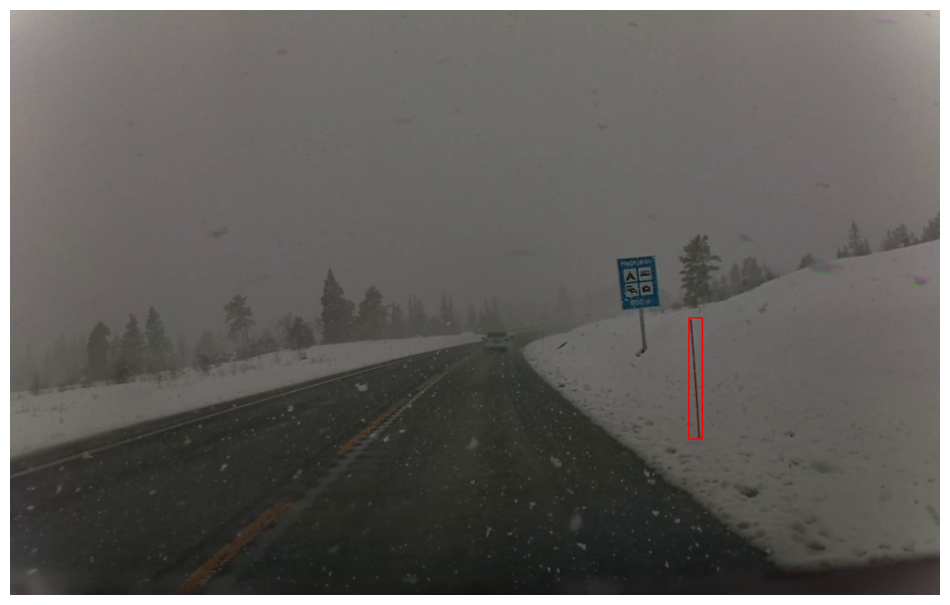

i=32
frame_001050


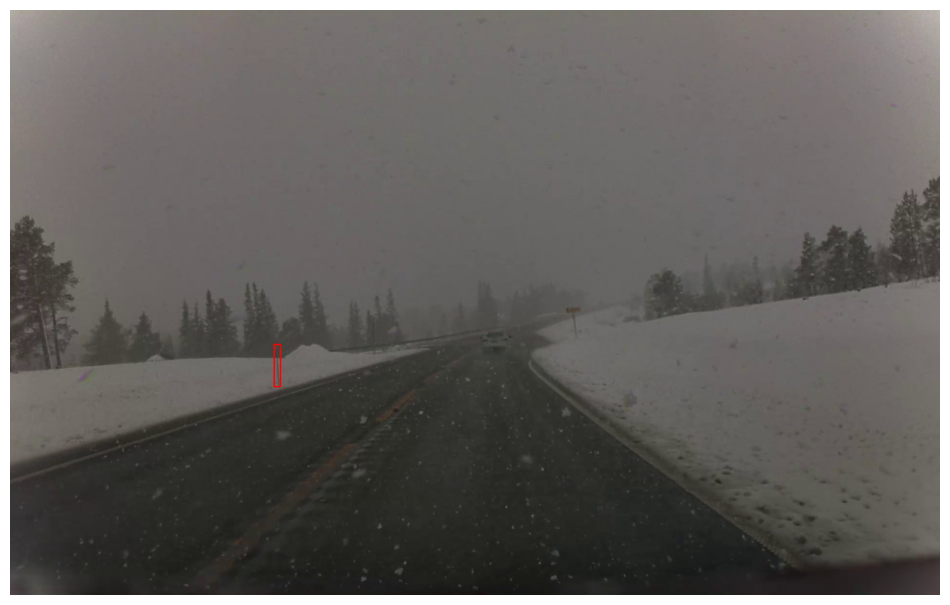

i=64
frame_002965


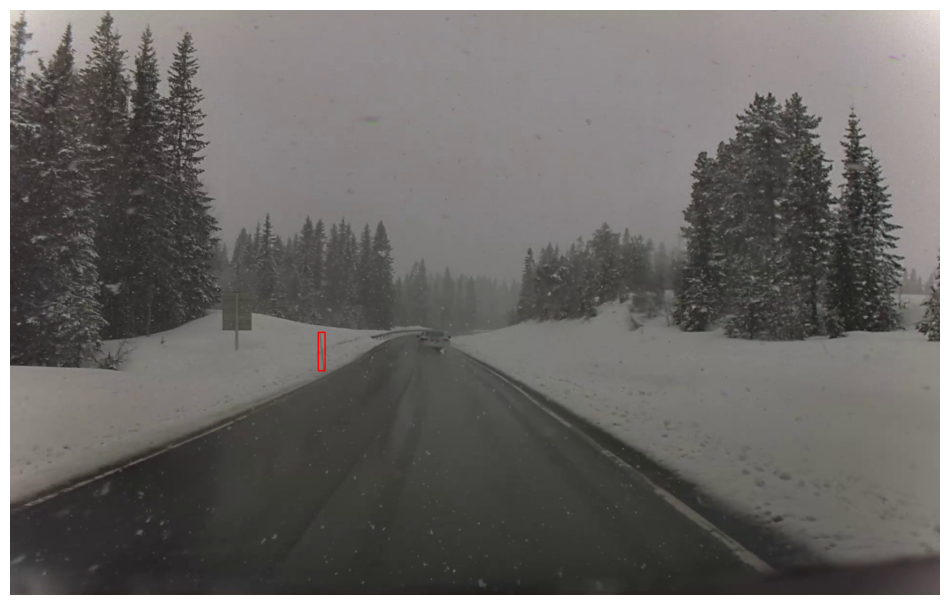

i=96
frame_003170


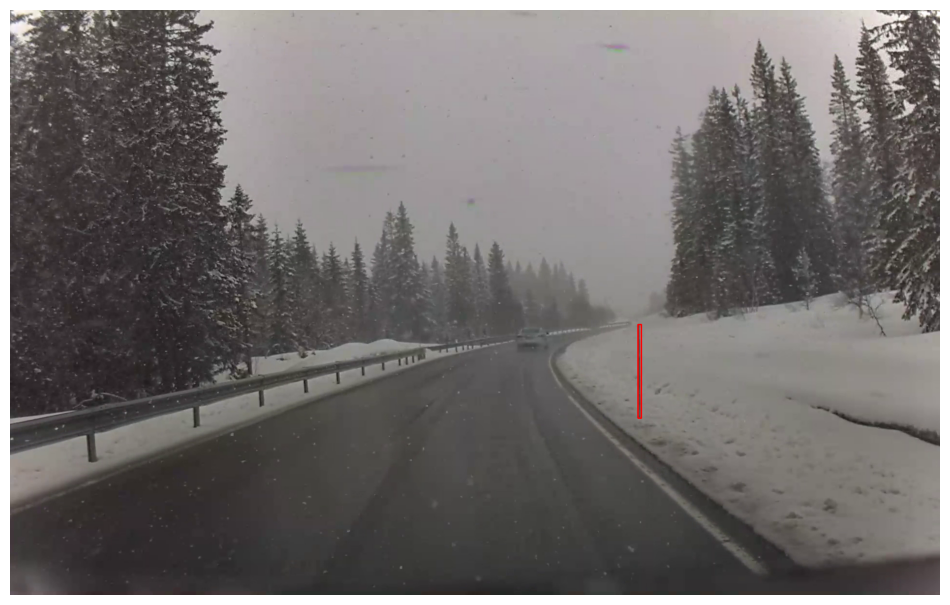

i=128
frame_005260


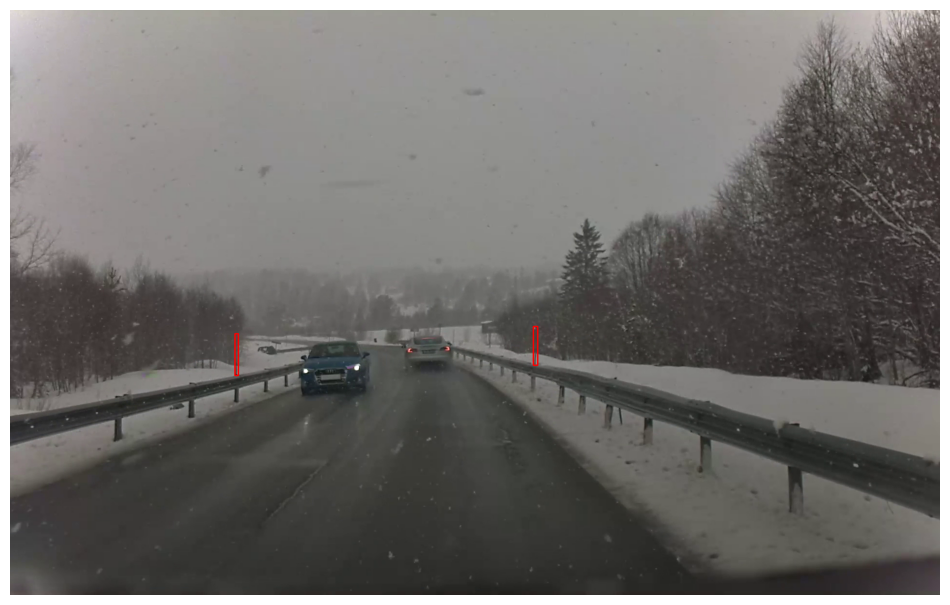

i=160
frame_000665


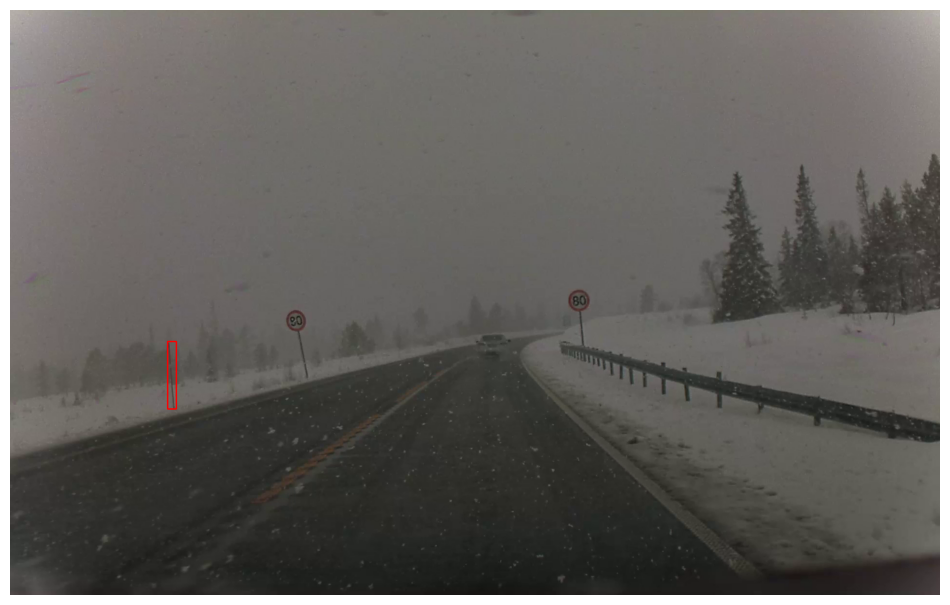

i=192
frame_004895


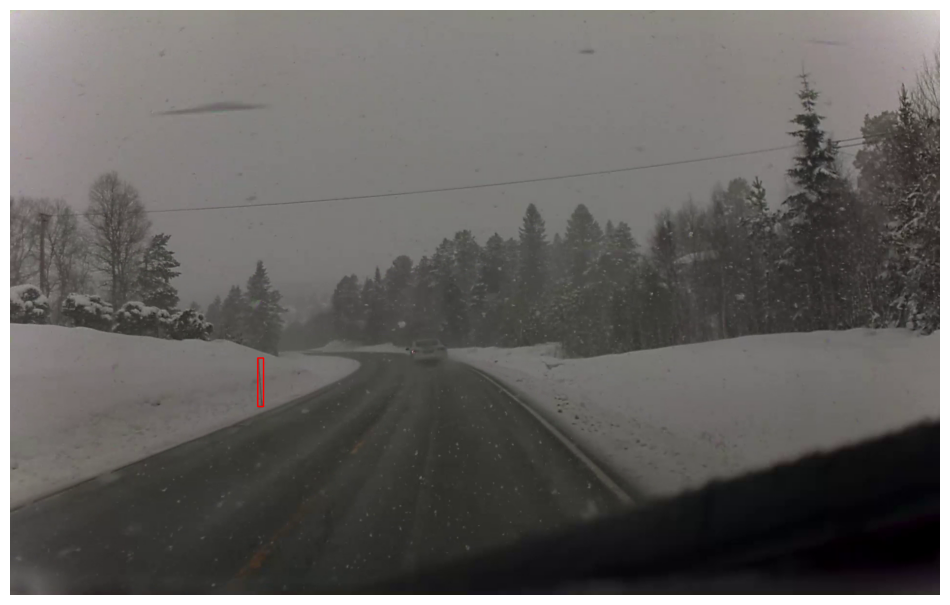

i=224
frame_001395


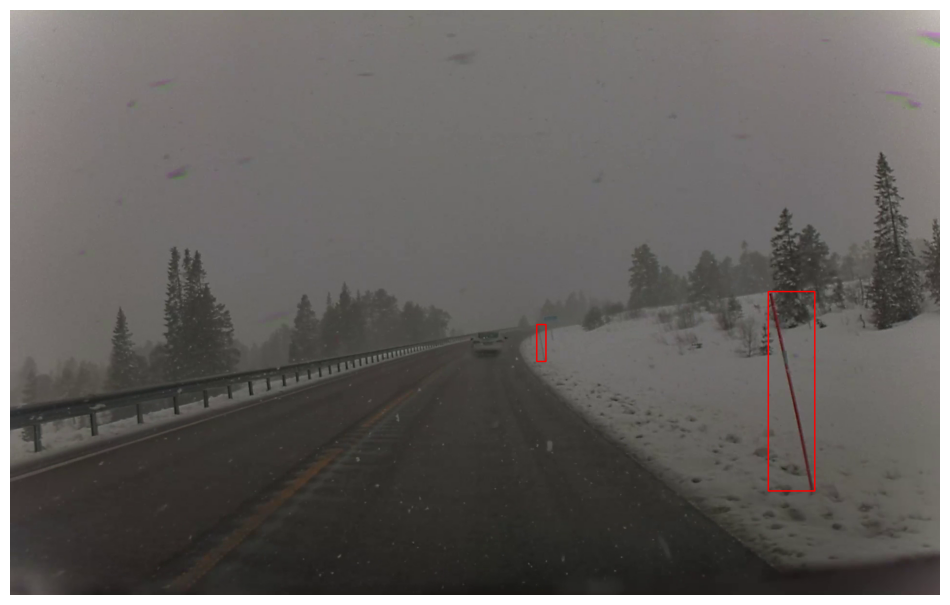

i=256
frame_001530


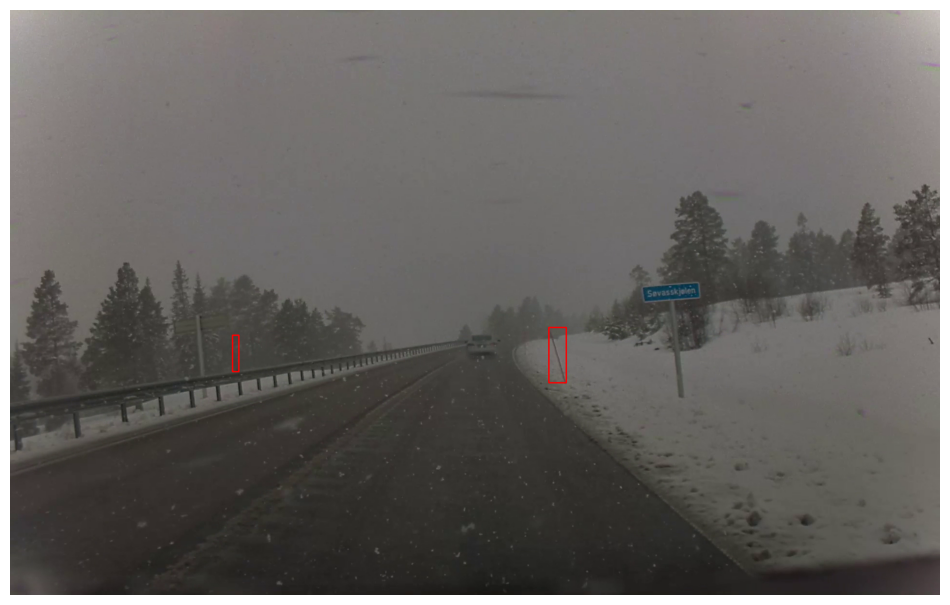

i=288
frame_005225


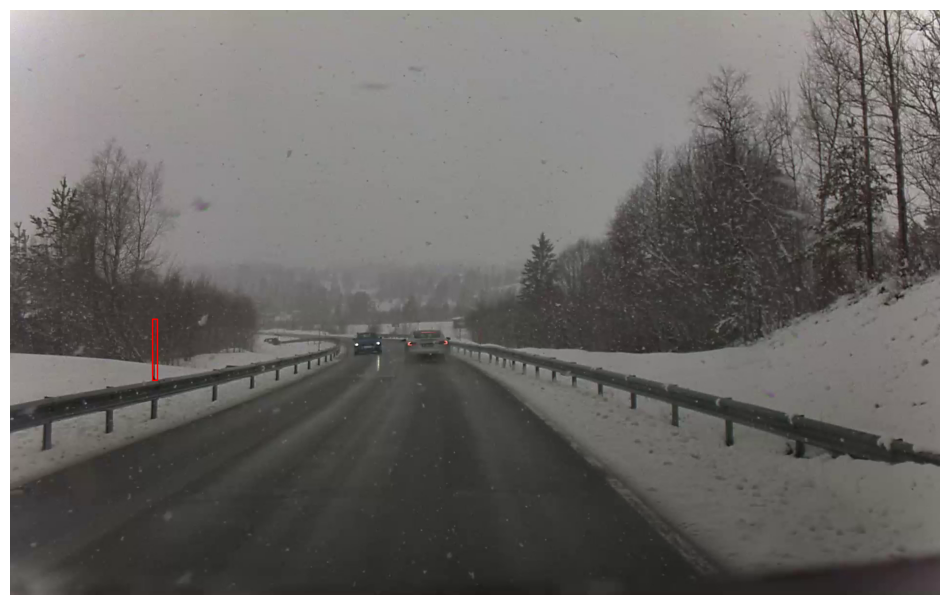

i=320
frame_000010


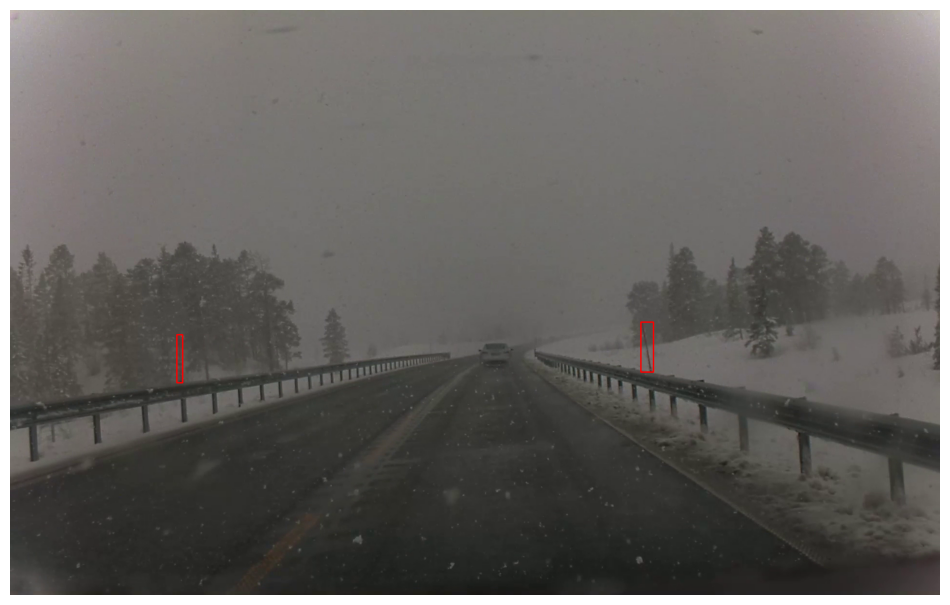

In [3]:
# build dataset
train_img_folder_path = '/cluster/projects/vc/courses/TDT17/ad/Poles2025/roadpoles_v1/train/images/' # .PNG
train_label_folder_path = '/cluster/projects/vc/courses/TDT17/ad/Poles2025/roadpoles_v1/train/labels/' # .txt
train_frames = []
for fname in os.listdir(train_label_folder_path):
    train_frames.append(fname[:-4])


nframes = len(train_frames); print('nr train frames:', nframes)
stopidx = 100
for i in range(0, len(train_frames), nframes//10):
    frame = train_frames[i]
    print(f'{i=}')
    print(frame)
    img_path = os.path.join(train_img_folder_path, frame + '.PNG')
    label_path = os.path.join(train_label_folder_path, frame + '.txt')

    img = cv2.imread(img_path)         
    h, w, _ = img.shape

    yolo_boxes = np.array(
        [list(map(float, line.split()[1:5])) for line in open(label_path)],
        dtype=np.float32
    )   # shape [N, 4] in (cx, cy, w, h) normalized

    #print('boxes norm', yolo_boxes)
    cx = yolo_boxes[:, 0] * w
    cy = yolo_boxes[:, 1] * h
    bw = yolo_boxes[:, 2] * w
    bh = yolo_boxes[:, 3] * h

    x1 = cx - bw / 2
    y1 = cy - bh / 2
    x2 = cx + bw / 2
    y2 = cy + bh / 2
    
    boxes_xyxy = np.stack([x1, y1, x2, y2], axis=1).astype(np.float32)
    #print("boxes_xyxy:", boxes_xyxy)

    # ---- 3) Build Detections (one class: 0) ----
    class_ids = np.zeros(len(boxes_xyxy), dtype=int)
    detections = sv.Detections(
        xyxy=boxes_xyxy,
        class_id=class_ids,
    )

    # ---- 4) Annotate ----
    box_annotator = sv.BoxAnnotator(color=sv.Color.RED)
    annotated_frame = box_annotator.annotate(scene=img, detections=detections)

    sv.plot_image(annotated_frame)  # supervision handles BGR/RGB internally
    


### Val data

In [ ]:
# build dataset
train_img_folder_path = '/cluster/projects/vc/courses/TDT17/ad/Poles2025/roadpoles_v1/valid/images/' # .PNG
train_label_folder_path = '/cluster/projects/vc/courses/TDT17/ad/Poles2025/roadpoles_v1/valid/labels/' # .txt
train_frames = []
for fname in os.listdir(train_label_folder_path):
    train_frames.append(fname[:-4])


nframes = len(train_frames); print('nr train frames:', nframes)
stopidx = 100
for i in range(0, len(train_frames), 3):
    frame = train_frames[i]
    print(f'{i=}')
    print(frame)
    img_path = os.path.join(train_img_folder_path, frame + '.PNG')
    label_path = os.path.join(train_label_folder_path, frame + '.txt')

    img = cv2.imread(img_path)         
    h, w, _ = img.shape

    yolo_boxes = np.array(
        [list(map(float, line.split()[1:5])) for line in open(label_path)],
        dtype=np.float32
    )   # shape [N, 4] in (cx, cy, w, h) normalized

    #print('boxes norm', yolo_boxes)
    cx = yolo_boxes[:, 0] * w
    cy = yolo_boxes[:, 1] * h
    bw = yolo_boxes[:, 2] * w
    bh = yolo_boxes[:, 3] * h

    x1 = cx - bw / 2
    y1 = cy - bh / 2
    x2 = cx + bw / 2
    y2 = cy + bh / 2
    
    boxes_xyxy = np.stack([x1, y1, x2, y2], axis=1).astype(np.float32)
    #print("boxes_xyxy:", boxes_xyxy)

    # ---- 3) Build Detections (one class: 0) ----
    class_ids = np.zeros(len(boxes_xyxy), dtype=int)
    detections = sv.Detections(
        xyxy=boxes_xyxy,
        class_id=class_ids,
    )

    # ---- 4) Annotate ----
    box_annotator = sv.BoxAnnotator(color=sv.Color.RED)
    annotated_frame = box_annotator.annotate(scene=img, detections=detections)

    sv.plot_image(annotated_frame)  # supervision handles BGR/RGB internally
    


### Test

In [ ]:
# build dataset
import matplotlib.image as mpimg  

train_img_folder_path = '/cluster/projects/vc/courses/TDT17/ad/Poles2025/roadpoles_v1/test/images/' # .PNG
train_frames = []
for fname in os.listdir(train_img_folder_path):
    train_frames.append(fname[:-4])


nframes = len(train_frames); print('nr train frames:', nframes)
stopidx = 100
for i in range(0, len(train_frames)):
    frame = train_frames[i]
    print(f'{i=}')
    print(frame)
    img_path = os.path.join(train_img_folder_path, frame + '.PNG')

    img = mpimg.imread(img_path)   # ← load image as array

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(frame)
    plt.show()
